In [1]:
import os
os.chdir('/Users/krittitee/Compro2_DataExploration')  ## directory in your computer where you store your titanic_data.csv
os.getcwd()

'/Users/krittitee/Compro2_DataExploration'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
%matplotlib inline

In [3]:
df = pd.read_csv("titanic_data.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Check data size and data types

In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## Handle missing data

In [7]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

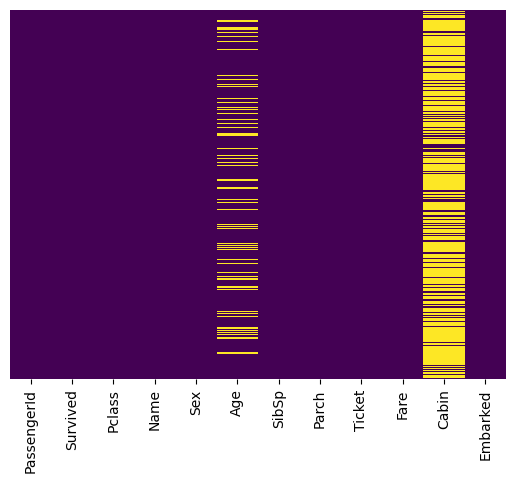

In [9]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

In [10]:
# Count missing values for each column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# Find missing value percent for each column
null_percent = df.isnull().sum()/len(df)*100
null_percent

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [12]:
# Create duplicate datafram of df
new_df = df.copy()

In [13]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

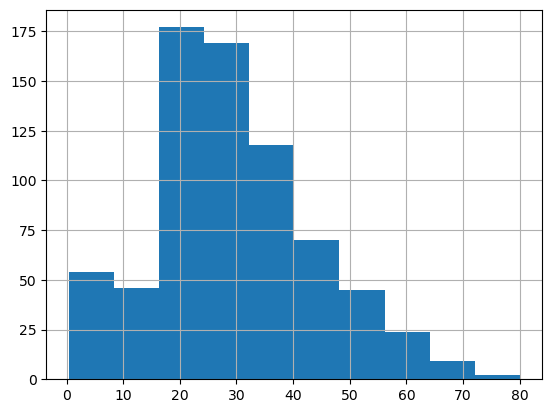

In [14]:
# To handle missing values in "Age" column, look at the histogram
var_ = 'Age'
new_df[var_].hist()
plt.show()

In [15]:
# Get value of mean
new_df[var_].mean()

np.float64(29.69911764705882)

In [16]:
# Get value of median
new_df[var_].median()

28.0

In [17]:
# Replace with median
new_df[var_] = new_df[var_].fillna(df[var_].median())
new_df[var_].mean()

np.float64(29.36158249158249)

In [18]:
# Find missing value percent for each column
null_percent = df.isnull().sum()/len(df)*100
null_percent

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [19]:
# To handle missing values in "Embarked" column, see its possible values
var2_ = 'Embarked'
new_df[var2_].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [20]:
# Find frequencies
new_df[var2_].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [21]:
# Replace missing values with ???
new_df[var2_] = new_df[var2_].fillna('S')  

In [22]:
# Find missing value percent for each column
null_percent = df.isnull().sum()/len(df)*100
null_percent

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [23]:
# To handle missing values in "Cabin" column, see its possible values
var3_ = 'Cabin'
new_df[var3_].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [24]:
# Drop column with missing values
new_df.drop([var3_], inplace=True, axis=1)

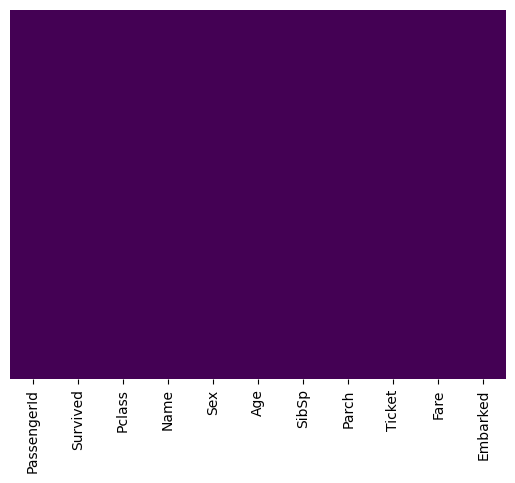

In [25]:
# Plot heaptmap again
sns.heatmap(new_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

In [26]:
# Re-check %missing data
new_df.isnull().sum()/len(new_df)*100

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [27]:
# See the dimension of updated dataframe
new_df.shape

(891, 11)

## Data Distributions / Histograms

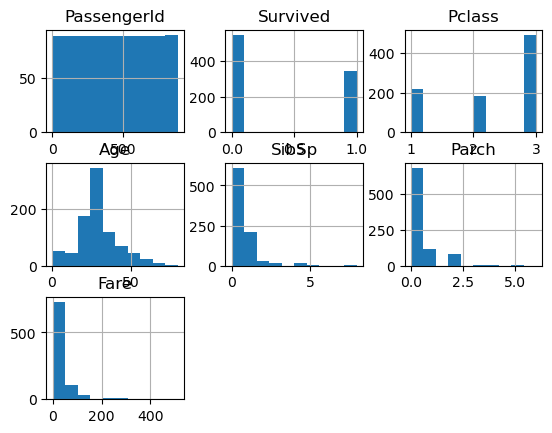

In [28]:
new_df.hist()
plt.show()

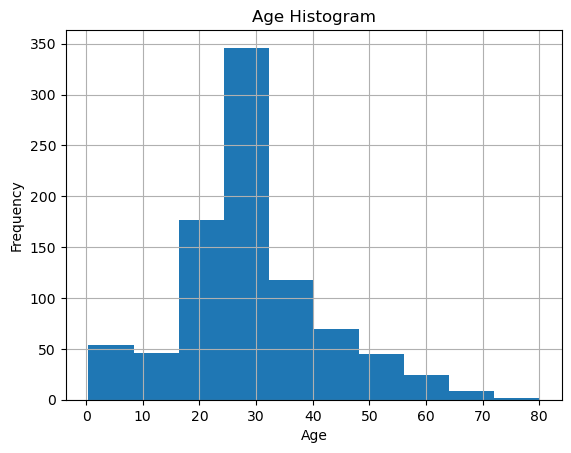

In [29]:
# Plot a single histogram for Age
selected_var = 'Age'

#new_df.hist(column=selected_var)
new_df[selected_var].hist()
#new_df.Age.hist()

plt.title(selected_var + ' Histogram')
plt.xlabel(selected_var)
plt.ylabel('Frequency')
plt.show()

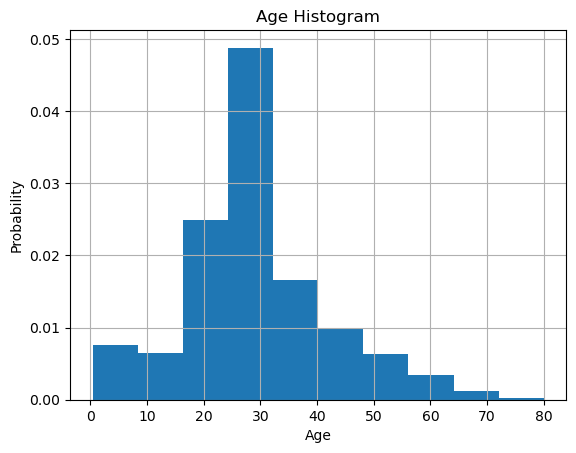

In [30]:
# Plot a single histogram 
new_df.hist(column=selected_var, density=True)
plt.title(selected_var + ' Histogram')
plt.xlabel(selected_var)
plt.ylabel('Probability')
plt.show()

In [31]:
# Get basic statistics 
new_df[selected_var].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

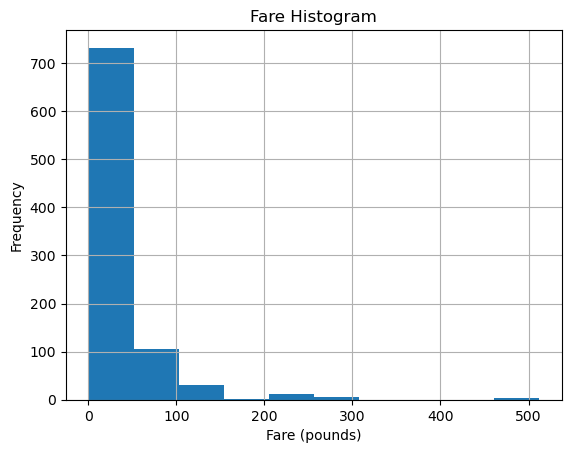

In [32]:
# Plot a single histogram for Fare
selected_var2 = 'Fare'
new_df[selected_var2].hist()
plt.title(selected_var2 + ' Histogram')
plt.xlabel('Fare (pounds)')
plt.ylabel('Frequency')
plt.show()

In [33]:
# Get basic statistics for Fare
new_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

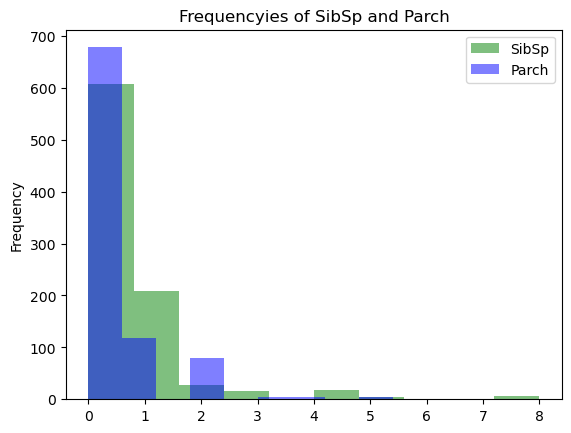

In [34]:
# Plot overlay histogram for SibSp and Parch
pair_var1 = 'SibSp'
pair_var2 = 'Parch'
plt.hist(new_df.SibSp, label=pair_var1, color='green', alpha=0.5)
plt.hist(new_df.Parch, label=pair_var2, color='blue', alpha=0.5)

plt.legend()
plt.title('Frequencyies of ' + pair_var1 + ' and ' + pair_var2)
plt.ylabel('Frequency')
plt.show()

## Boxplots

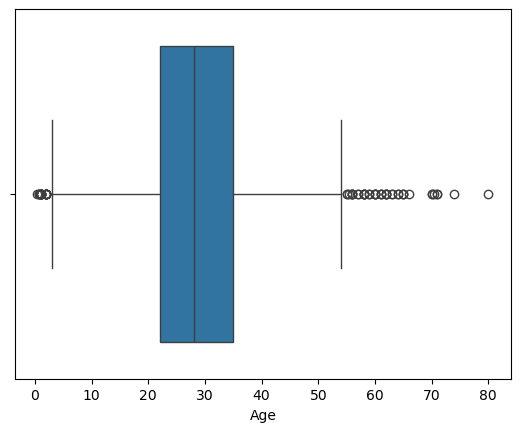

In [35]:
# Plot a boxplot for Age
sns.boxplot(x='Age', data=new_df)
plt.show()

In [36]:
new_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

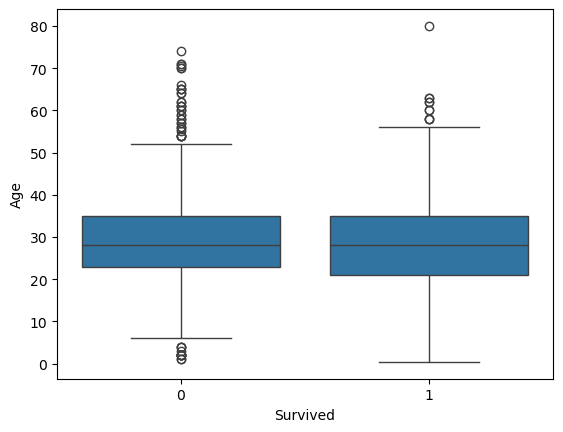

In [37]:
# Plot a boxplot
x_var = 'Survived'
sns.boxplot(x=x_var,y='Age', data=new_df)
plt.show()

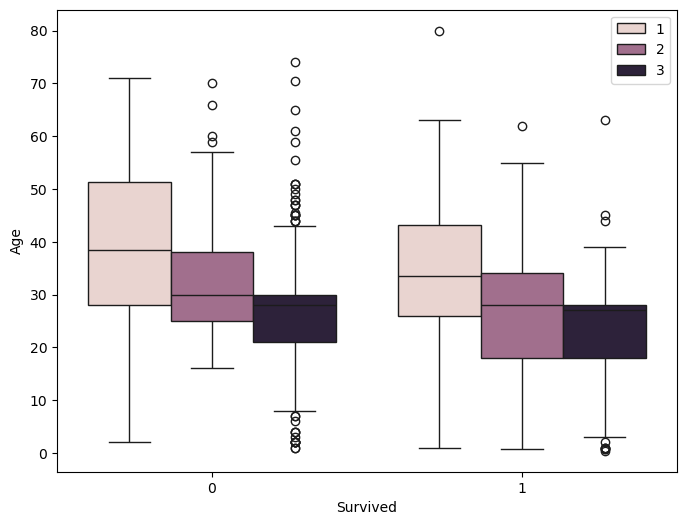

In [38]:
# Plot a boxplot
fig = plt.figure(figsize = (8,6))
hue_var = 'Pclass'
sns.boxplot(x='Survived',y='Age', data=new_df, hue='Pclass')
plt.legend(loc='upper right')
plt.show()

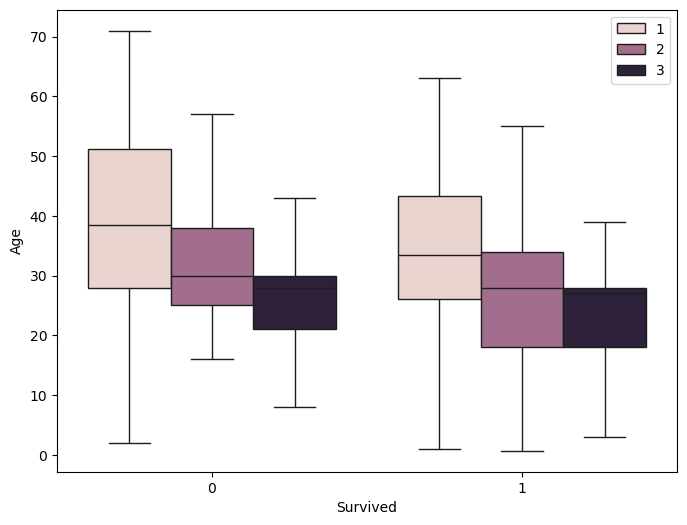

In [39]:
# Plot a boxplot
fig = plt.figure(figsize = (8,6))
sns.boxplot(x='Survived',y='Age', data=new_df, hue='Pclass',showfliers=False)
plt.legend(loc='upper right')
plt.show()

## Descriptive Statistics : Centrality and Dispersion

In [40]:
new_df.mean(numeric_only=True)
#new_df.mean()

PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.361582
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

In [41]:
# Check data types 
new_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [42]:
# Get the column names
new_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [54]:
# Extract numerical data
num_columns = ['Survived', 'Age', 'SibSp', 'Parch', 'Fare',]
num_df = new_df[num_columns]

In [44]:
# Get basic statistics
num_df.describe()

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,0.523008,0.381594,32.204208
std,13.019697,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


In [45]:
# Use specific function to get specific statistic (mean)
num_df.mean()

Age      29.361582
SibSp     0.523008
Parch     0.381594
Fare     32.204208
dtype: float64

In [46]:
# Use specific function to get specific statistic (mode)
#num_df.mode()
num_df.mode().loc[0,]

Age      28.00
SibSp     0.00
Parch     0.00
Fare      8.05
Name: 0, dtype: float64

In [55]:
# Use specific function to get specific statistic (mean) for specific value
num_df.groupby('Survived').mean()

,Age,SibSp,Parch,Fare
Survived,,,,
0,30.028233,0.553734,0.329690,22.117887
1,28.291433,0.473684,0.464912,48.395408


In [48]:
# Standard deviation
num_df.std()

Age      13.019697
SibSp     1.102743
Parch     0.806057
Fare     49.693429
dtype: float64

In [49]:
# IQR
num_df.quantile(0.75) - num_df.quantile(0.25)

Age      13.0000
SibSp     1.0000
Parch     0.0000
Fare     23.0896
dtype: float64

In [50]:
# Coefficient of variation
num_df.std() / num_df.mean()

Age      0.443426
SibSp    2.108464
Parch    2.112344
Fare     1.543073
dtype: float64

In [51]:
# Skewness
num_df.skew()

Age      0.510245
SibSp    3.695352
Parch    2.749117
Fare     4.787317
dtype: float64

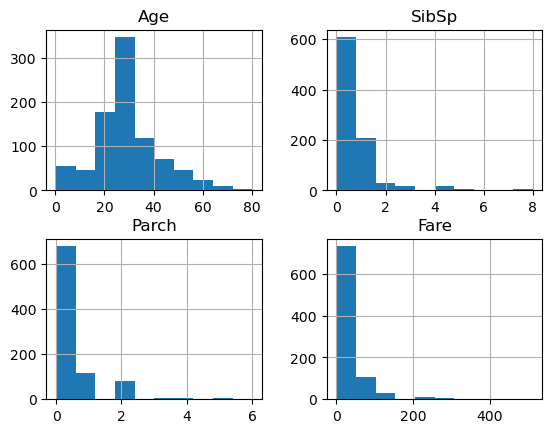

In [52]:
num_df.hist()
plt.show()

## Outlier Removals

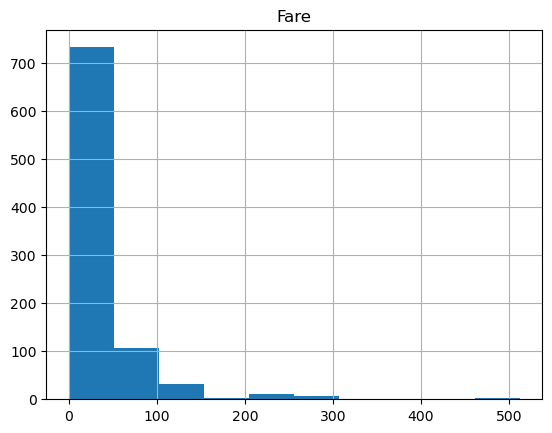

In [53]:
# Plot a histogram for Fare
outlier_var = 'Fare'
num_df.hist(column=outlier_var)
plt.show()

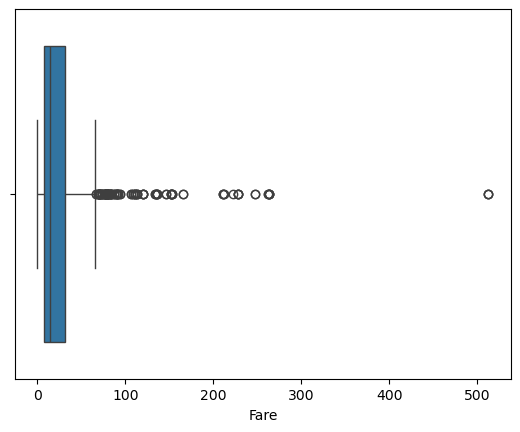

In [56]:
# Plot a boxplot
sns.boxplot(x=outlier_var, data=num_df)
plt.show()

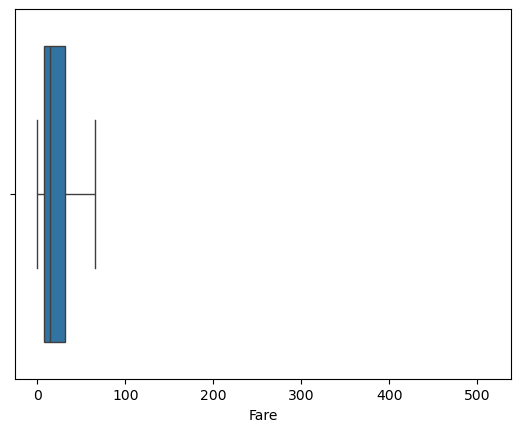

In [57]:
# Plot a boxplot
sns.boxplot(x=outlier_var, data=num_df, fliersize=0)
#https://seaborn.pydata.org/generated/seaborn.boxplot.html
plt.show()

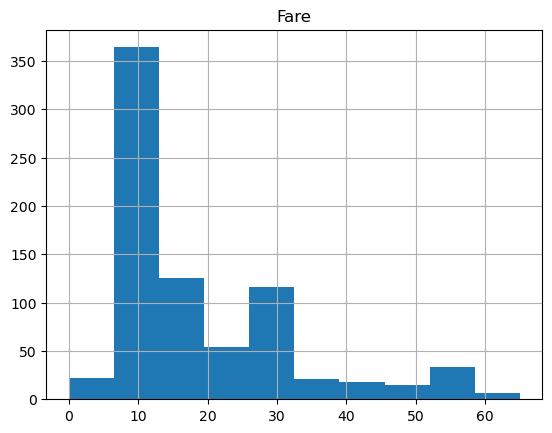

In [58]:
# Outliers removals by IQR-based
q1 = num_df[outlier_var].quantile(0.25)
q3 = num_df[outlier_var].quantile(0.75)
iqr = q3-q1
temp_df = num_df[~((num_df[outlier_var] < q1-1.5*iqr) | (num_df[outlier_var] > q3+1.5*iqr))]
temp_df.hist(column=outlier_var)
plt.show()

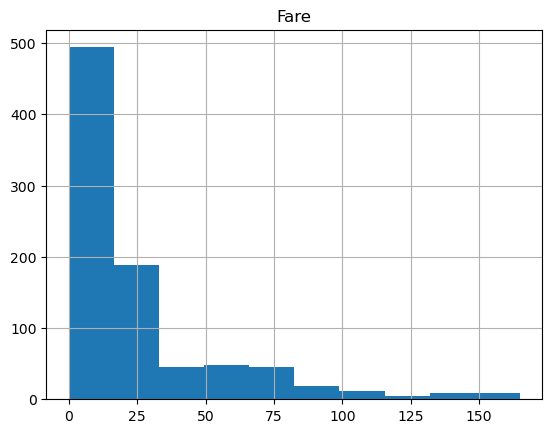

In [59]:
# Outliers removals by SD-based
mean = num_df[outlier_var].mean()
sd = num_df[outlier_var].std()
temp_df2 = num_df[~((num_df[outlier_var] < mean-3*sd) | (num_df[outlier_var] > mean+3*sd))]
temp_df2.hist(column=outlier_var)
plt.show()

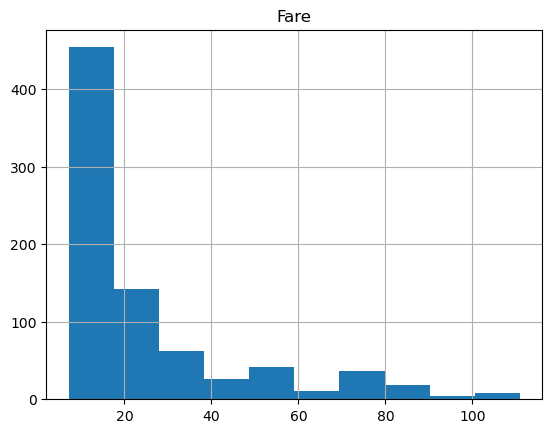

In [60]:
# Outliers removals by 5% and 95% percentiles
p05 = num_df[outlier_var].quantile(0.05)
p95 = num_df[outlier_var].quantile(0.95)
temp_df3 = num_df[~((num_df[outlier_var] < p05) | (num_df[outlier_var] > p95))]
temp_df3.hist(column=outlier_var)
plt.show()

In [61]:
print(temp_df.shape)
print(temp_df2.shape)
print(temp_df3.shape)

(775, 5)
(871, 5)
(803, 5)


## Scatter Plots and Correlation

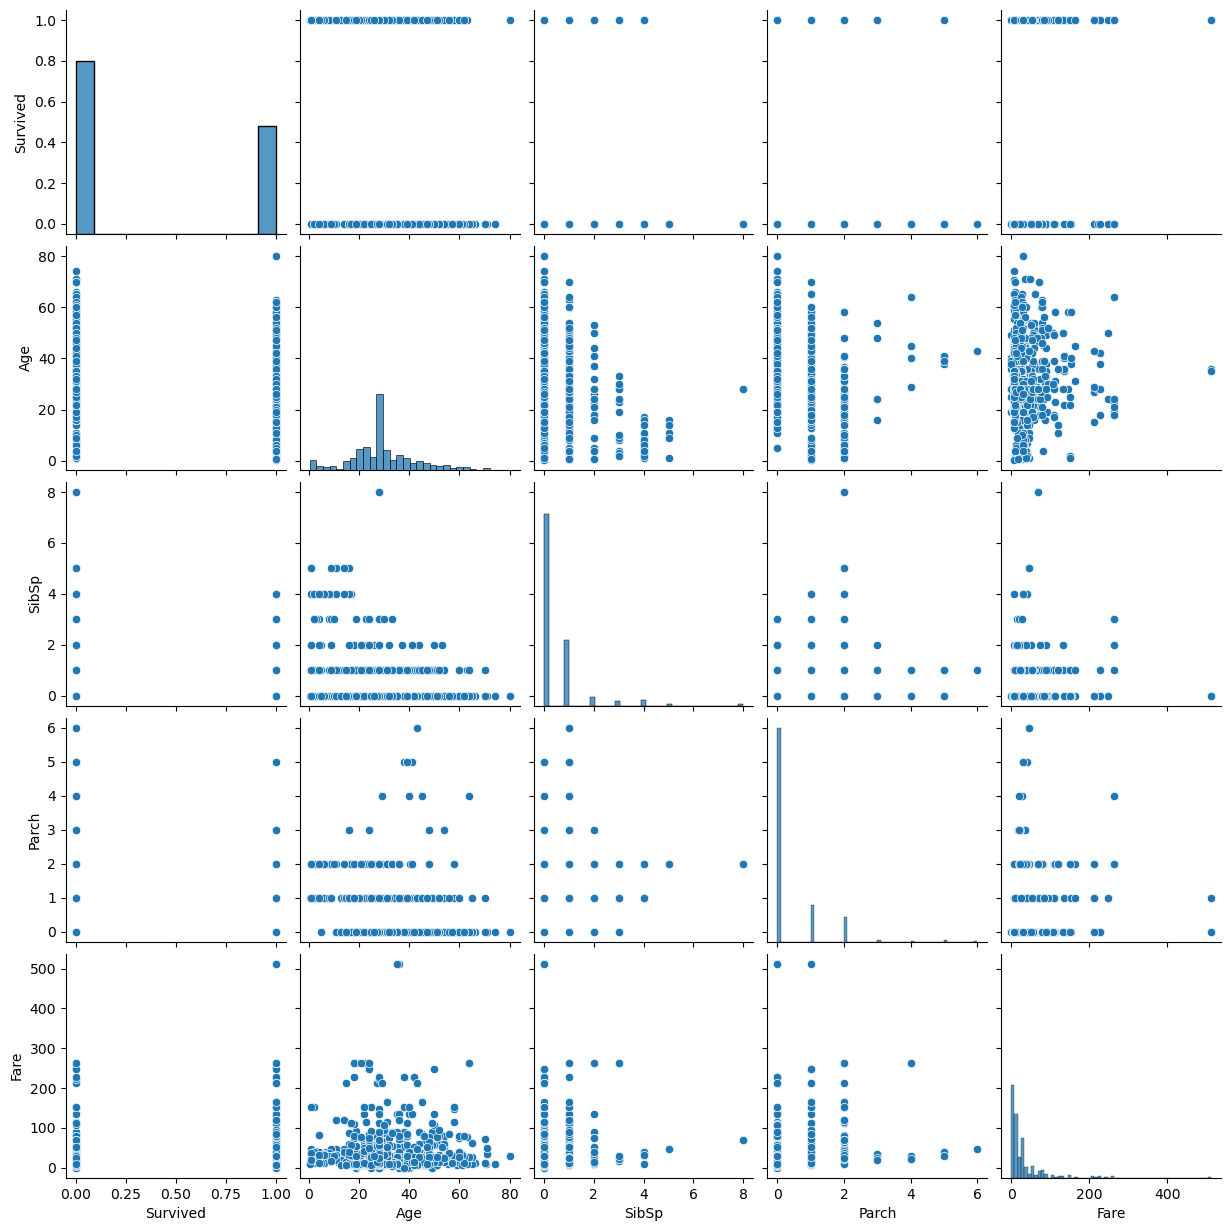

In [62]:
sns.pairplot(num_df)
plt.show()

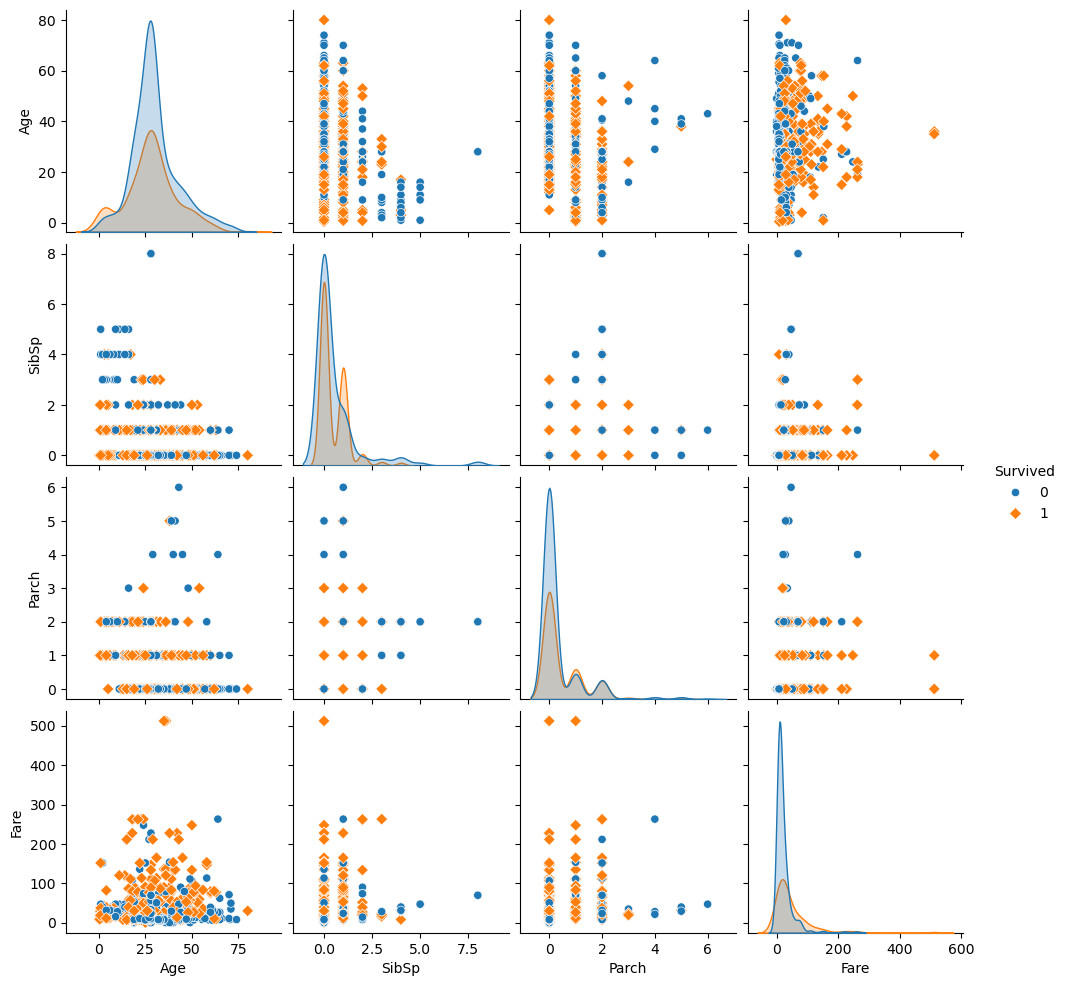

In [63]:
hue_var = 'Survived'
sns.pairplot(num_df,hue=hue_var, markers=["o", "D"])
plt.show()

KeyError: 'Pclass'

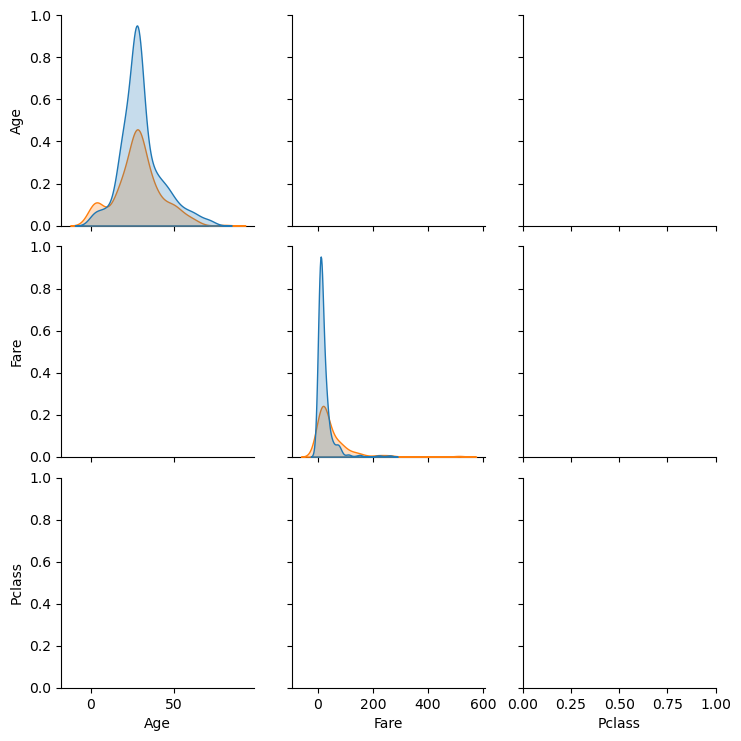

In [64]:
sns.pairplot(num_df, vars = ['Age', 'Fare', 'Pclass'], hue=hue_var, markers=["o", "D"])
plt.show()

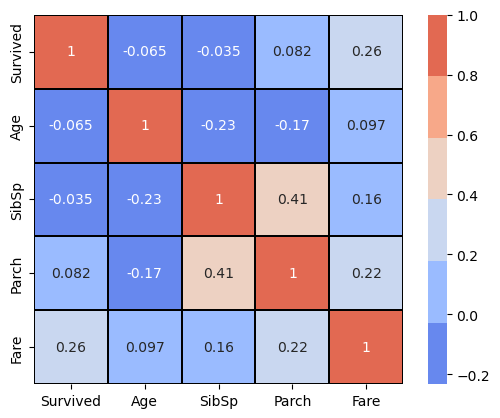

In [65]:
sns.heatmap(num_df.corr(),
            square=True,
            linewidths=0.25,
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=True)
plt.show()

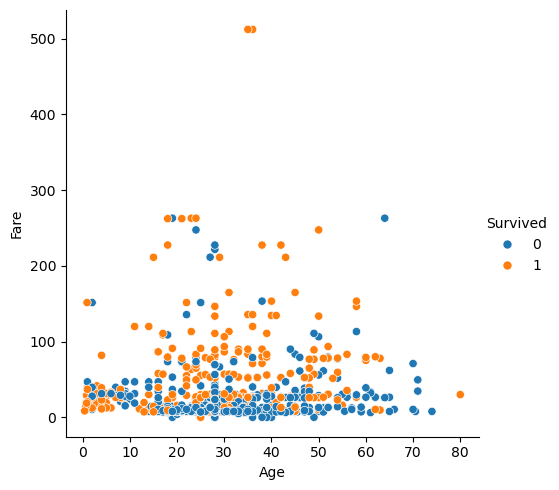

In [66]:
sns.relplot(data=num_df,
            x="Age",
            y="Fare",
            hue=hue_var)
plt.show()

In [67]:
sns.relplot(data=num_df,
            x="Age",
            y="Fare",
            hue=hue_var,
            size="Pclass",
            sizes=(20, 100),
            alpha=0.8,
            palette=sns.color_palette("muted",len(num_df['Survived'].unique())))
plt.show()

ValueError: Could not interpret value `Pclass` for `size`. An entry with this name does not appear in `data`.